# 🚗 Vehicle CO₂ Emissions — Complete EDA

**Objective:** Explore vehicle specifications, fuel consumption, fuel types, and CO₂ emissions to identify patterns, relationships, outliers, and useful insights.

### Analysis included
- Dataset overview and data quality
- Descriptive statistics
- Categorical analysis
- Numerical distributions
- Box plots and outlier analysis
- Bivariate analysis
- Fuel type and vehicle class comparisons
- Manufacturer analysis
- Correlation analysis
- Top/bottom vehicles by CO₂ emissions
- Model-year analysis
- Fuel economy vs emissions
- Final findings and further analysis ideas

> ⭐ **Important Point:** This notebook is structured as a complete EDA portfolio project.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

df = pd.read_csv("C:/Users/pradh/Downloads/FuelConsumption.csv")
df.head()


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.00,4,AS5,Z,9.90,6.70,8.50,33,196
1,2014,ACURA,ILX,COMPACT,2.40,4,M6,Z,11.20,7.70,9.60,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.50,4,AV7,Z,6.00,5.80,5.90,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.50,6,AS6,Z,12.70,9.10,11.10,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.50,6,AS6,Z,12.10,8.70,10.60,27,244


## 1. Dataset Overview

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())


Rows: 1067
Columns: 13

Column Names:
['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS', 'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
MODELYEAR,1067.00,NaN,NaN,NaN,2014.00,0.00,2014.00,2014.00,2014.00,2014.00,2014.00
MAKE,1067,39,FORD,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MODEL,1067,663,F150 FFV,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VEHICLECLASS,1067,16,MID-SIZE,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,1067.00,NaN,NaN,NaN,3.35,1.42,1.00,2.00,3.40,4.30,8.40
CYLINDERS,1067.00,NaN,NaN,NaN,5.79,1.80,3.00,4.00,6.00,8.00,12.00
TRANSMISSION,1067,22,A6,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FUELTYPE,1067,4,X,514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FUELCONSUMPTION_CITY,1067.00,NaN,NaN,NaN,13.30,4.10,4.60,10.25,12.60,15.55,30.20
FUELCONSUMPTION_HWY,1067.00,NaN,NaN,NaN,9.47,2.79,4.90,7.50,8.80,10.85,20.50


### 🔎 Insight

- The dataset contains vehicle specifications, fuel-consumption measures, and CO₂ emissions.
- Numerical variables include engine size, cylinders, fuel consumption, MPG, and CO₂ emissions.
- Categorical variables include manufacturer, model, vehicle class, transmission, and fuel type.

> ⭐ **Important Point:** The dataset combines vehicle characteristics with environmental measures, making it suitable for emission-focused EDA.


## 2. Data Quality Check

In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

Duplicate rows: 0


In [8]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
display(missing_pct[missing_pct > 0])


Series([], dtype: float64)

### 🔎 Insight

- Check missing values and duplicates before analysis.
- A clean dataset reduces unexpected errors and improves the reliability of EDA.

> ⭐ **Important Point:** Data quality should be verified before drawing conclusions.


## 3. Unique Values in Categorical Columns

In [9]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))



MAKE: 39 unique values
MAKE
FORD             90
CHEVROLET        86
BMW              64
MERCEDES-BENZ    59
GMC              49
AUDI             49
TOYOTA           49
PORSCHE          44
VOLKSWAGEN       42
DODGE            39
Name: count, dtype: int64

MODEL: 663 unique values
MODEL
F150 FFV         8
F150 FFV 4X4     8
ACCORD           6
FOCUS FFV        6
BEETLE           6
PASSAT           5
SILVERADO 4WD    5
SILVERADO        5
MUSTANG          5
SIERRA           5
Name: count, dtype: int64

VEHICLECLASS: 16 unique values
VEHICLECLASS
MID-SIZE                   178
COMPACT                    172
SUV - SMALL                154
SUV - STANDARD             110
FULL-SIZE                   86
TWO-SEATER                  71
SUBCOMPACT                  65
PICKUP TRUCK - STANDARD     62
MINICOMPACT                 47
STATION WAGON - SMALL       36
Name: count, dtype: int64

TRANSMISSION: 22 unique values
TRANSMISSION
A6     222
AS6    189
M6     141
A8      87
AS8     80
AS7     76
M5   

## 4. Manufacturer Analysis

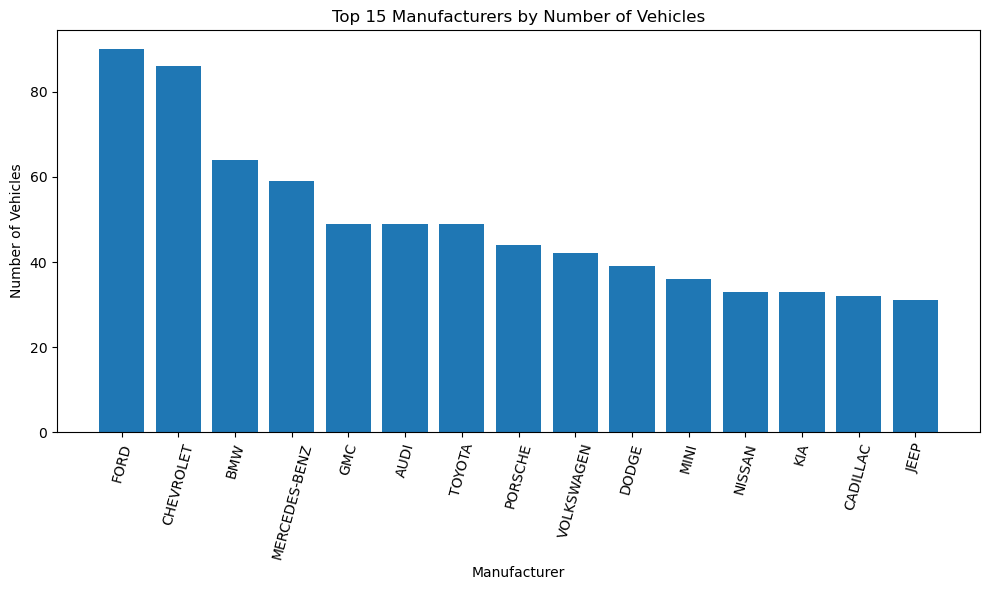

In [10]:
counts = df['MAKE'].value_counts().head(15)

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values)
plt.title('Top 15 Manufacturers by Number of Vehicles')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


### 🔎 Insight

- The dataset contains many manufacturers, but their representation is uneven.
- The most frequently represented manufacturers provide more observations for comparison.
- Manufacturer-level comparisons should consider sample size.

> ⭐ **Important Point:** A manufacturer with very few observations should be interpreted cautiously.


## 5. Fuel Type Analysis

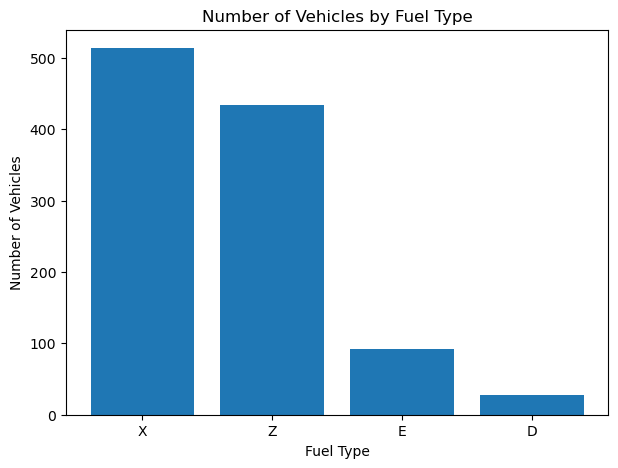

In [11]:
counts = df['FUELTYPE'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(counts.index, counts.values)
plt.title('Number of Vehicles by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Vehicles')
plt.show()


### 🔎 Insight

- Fuel type categories are not equally represented.
- The dataset is concentrated in the most common fuel categories.
- Less common fuel types have smaller sample sizes.

> ⭐ **Important Point:** Fuel-type comparisons should account for unequal observations.


## 6. Vehicle Class Analysis

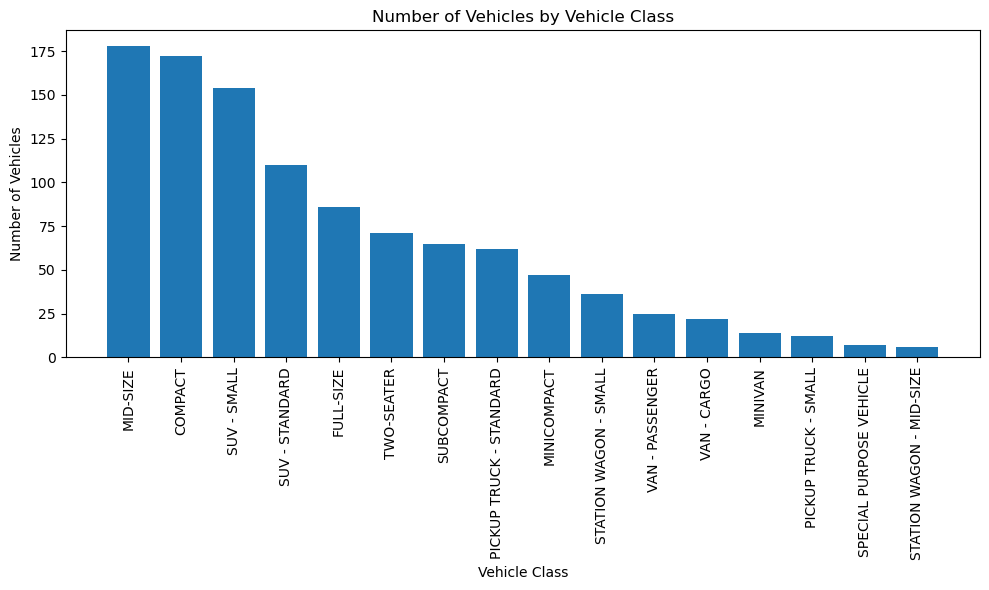

In [12]:
counts = df['VEHICLECLASS'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values)
plt.title('Number of Vehicles by Vehicle Class')
plt.xlabel('Vehicle Class')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### 🔎 Insight

- Mid-size, compact, and small SUV categories are strongly represented.
- Vehicle classes have different numbers of observations.
- Vehicle class is useful for understanding differences in fuel consumption and emissions.

> ⭐ **Important Point:** Comparisons between classes should consider both their emission levels and sample sizes.


## 7. Transmission Analysis

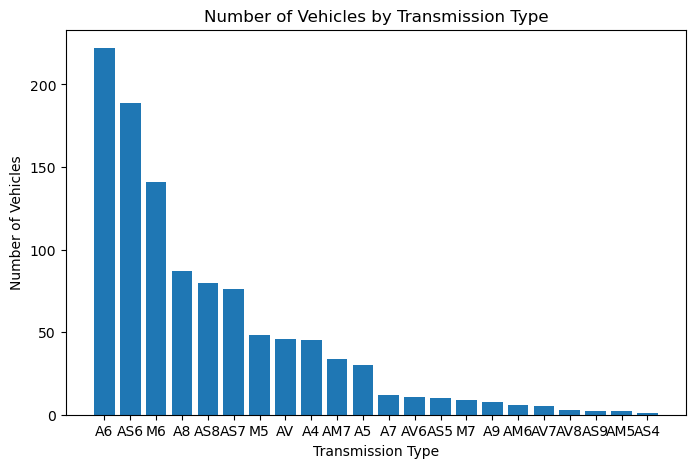

In [13]:
counts = df['TRANSMISSION'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.title('Number of Vehicles by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Number of Vehicles')
plt.show()


### 🔎 Insight

- Automatic and manual transmission categories make up most observations.
- Other transmission types are less common.
- Transmission can later be compared with fuel consumption and CO₂ emissions.

> ⭐ **Important Point:** Transmission type provides another useful dimension for efficiency analysis.


## 8. Engine Size Distribution

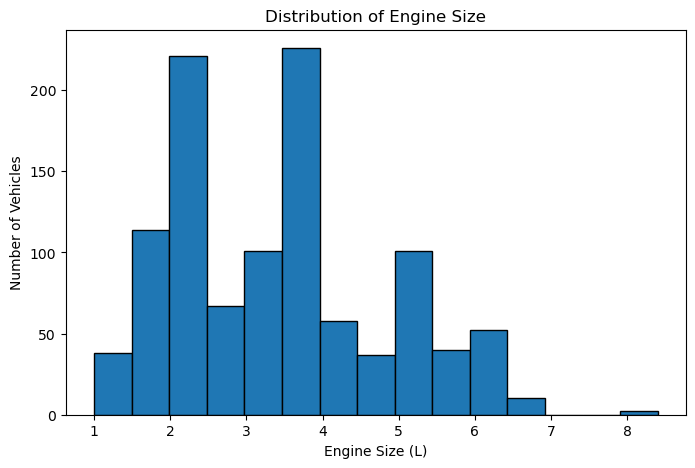

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df['ENGINESIZE'], bins=15, edgecolor='black')
plt.title('Distribution of Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('Number of Vehicles')
plt.show()


### 🔎 Insight

- Most vehicles have engine sizes concentrated around approximately **2L–4L**.
- Very large engines are relatively uncommon.
- The distribution has a tail toward larger engine sizes.

> ⭐ **Important Point:** Engine size is mainly concentrated in the moderate range.


## 9. Cylinder Count Distribution

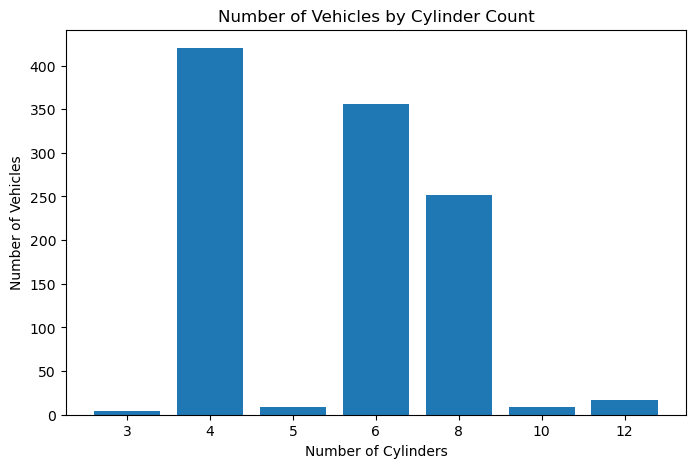

In [15]:
counts = df['CYLINDERS'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(counts.index.astype(str), counts.values)
plt.title('Number of Vehicles by Cylinder Count')
plt.xlabel('Number of Cylinders')
plt.ylabel('Number of Vehicles')
plt.show()


### 🔎 Insight

- **4-cylinder vehicles** are the most common.
- **6-cylinder vehicles** are the second most common.
- 8-cylinder vehicles are also represented significantly.
- 3, 5, 10, and 12-cylinder vehicles are comparatively uncommon.

> ⭐ **Important Point:** The dataset is mainly concentrated around **4, 6, and 8-cylinder vehicles**.


## 10. City Fuel Consumption Distribution

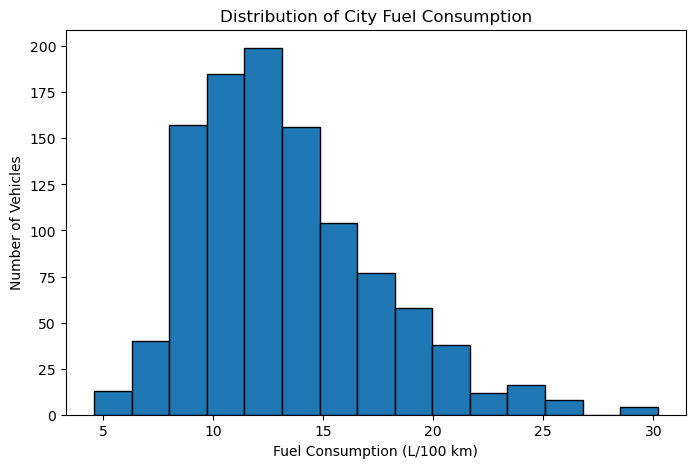

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df['FUELCONSUMPTION_CITY'], bins=15, edgecolor='black')
plt.title('Distribution of City Fuel Consumption')
plt.xlabel('Fuel Consumption (L/100 km)')
plt.ylabel('Number of Vehicles')
plt.show()


### 🔎 Insight

- Most vehicles have city fuel consumption around **8–15 L/100 km**.
- The highest concentration is around **10–13 L/100 km**.
- Very high city fuel consumption is less common.
- The distribution is right-skewed.

> ⭐ **Important Point:** Most vehicles have moderate city fuel consumption.


## 11. Highway Fuel Consumption Distribution

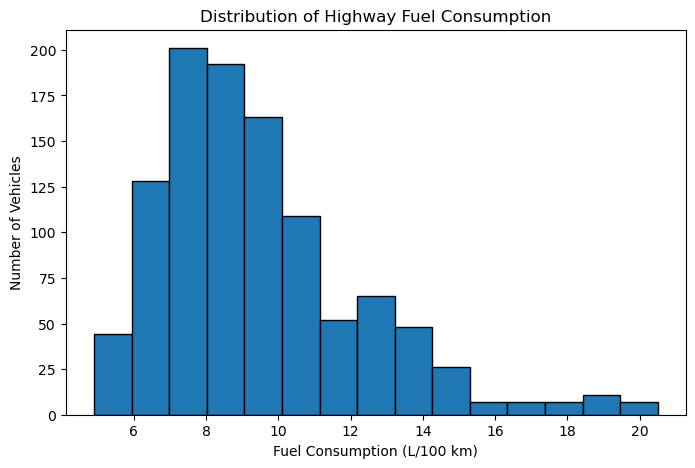

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df['FUELCONSUMPTION_HWY'], bins=15, edgecolor='black')
plt.title('Distribution of Highway Fuel Consumption')
plt.xlabel('Fuel Consumption (L/100 km)')
plt.ylabel('Number of Vehicles')
plt.show()


### 🔎 Insight

- Most vehicles have highway fuel consumption around **6–12 L/100 km**.
- The highest concentration is approximately **7–10 L/100 km**.
- Values above 15 L/100 km are relatively uncommon.
- The distribution is right-skewed.

> ⭐ **Important Point:** Highway fuel consumption is generally lower than city fuel consumption.


## 12. Combined Fuel Consumption Distribution

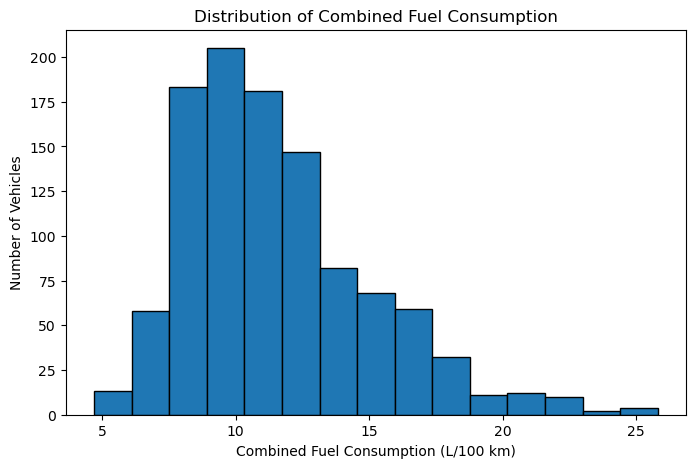

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df['FUELCONSUMPTION_COMB'], bins=15, edgecolor='black')
plt.title('Distribution of Combined Fuel Consumption')
plt.xlabel('Combined Fuel Consumption (L/100 km)')
plt.ylabel('Number of Vehicles')
plt.show()


### 🔎 Insight

- Most vehicles have combined fuel consumption between approximately **7 and 13 L/100 km**.
- The highest concentration is around **9–11 L/100 km**.
- Very high combined consumption is relatively uncommon.
- The distribution is right-skewed.

> ⭐ **Important Point:** Most vehicles have moderate combined fuel consumption.


## 13. Combined Fuel Consumption — Box Plot

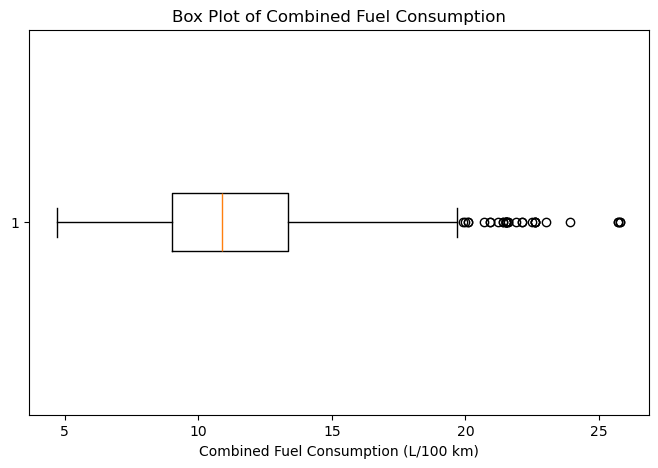

In [19]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['FUELCONSUMPTION_COMB'], vert=False)
plt.title('Box Plot of Combined Fuel Consumption')
plt.xlabel('Combined Fuel Consumption (L/100 km)')
plt.show()


### 🔎 Insight

- The median combined fuel consumption is around **11 L/100 km**.
- Most observations lie within the central interquartile range.
- Several high-value observations appear beyond the upper whisker.
- These points represent vehicles with unusually high fuel consumption.

> ⭐ **Important Point:** The box plot clearly highlights high-consumption outliers.


## 14. Combined MPG — Box Plot

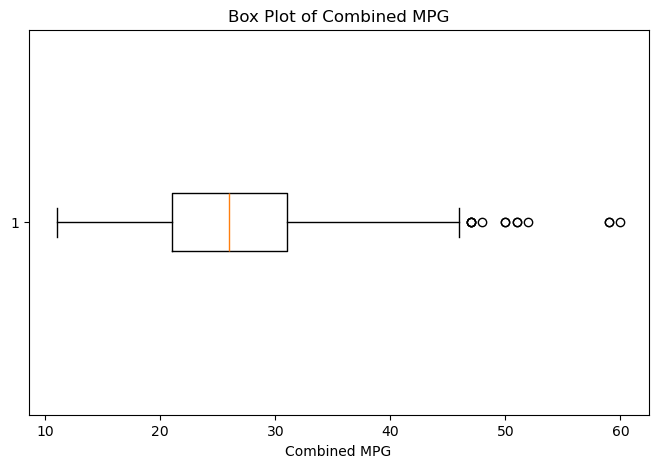

In [20]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['FUELCONSUMPTION_COMB_MPG'], vert=False)
plt.title('Box Plot of Combined MPG')
plt.xlabel('Combined MPG')
plt.show()


### 🔎 Insight

- MPG provides an inverse view of fuel consumption: higher MPG generally indicates better fuel economy.
- The box plot helps identify the central range and extreme fuel-economy observations.

> ⭐ **Important Point:** Higher MPG generally represents better fuel efficiency.


## 15. CO₂ Emissions Distribution

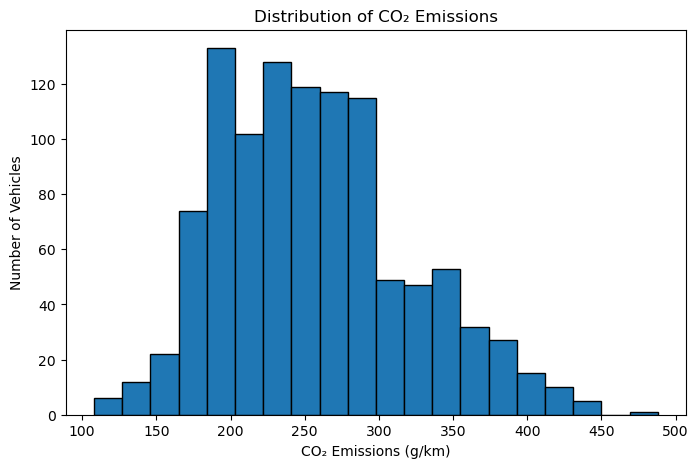

Mean CO₂: 256.23
Median CO₂: 251.0


In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df['CO2EMISSIONS'], bins=20, edgecolor='black')
plt.title('Distribution of CO₂ Emissions')
plt.xlabel('CO₂ Emissions (g/km)')
plt.ylabel('Number of Vehicles')
plt.show()

print("Mean CO₂:", round(df['CO2EMISSIONS'].mean(), 2))
print("Median CO₂:", round(df['CO2EMISSIONS'].median(), 2))


### 🔎 Insight

- CO₂ emissions vary substantially across vehicles.
- The mean and median describe the typical emission level.
- Higher-emission vehicles occupy the upper end of the distribution.

> ⭐ **Important Point:** CO₂ emissions vary considerably across different vehicle specifications.


## 16. CO₂ Emissions — Box Plot and Outliers

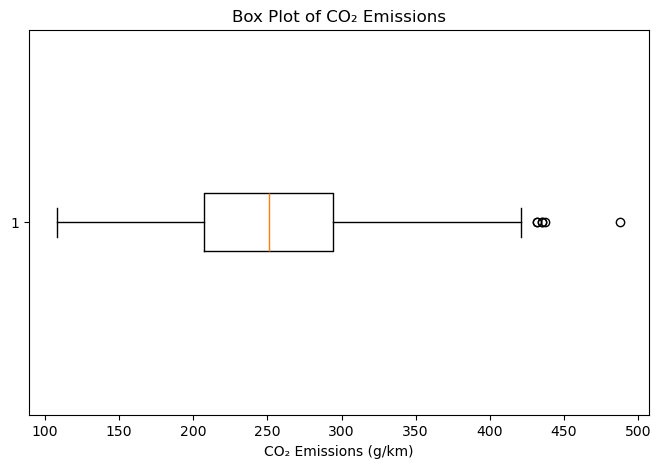

Lower bound: 76.5
Upper bound: 424.5
Number of CO₂ outliers: 6


In [22]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['CO2EMISSIONS'], vert=False)
plt.title('Box Plot of CO₂ Emissions')
plt.xlabel('CO₂ Emissions (g/km)')
plt.show()

Q1 = df['CO2EMISSIONS'].quantile(0.25)
Q3 = df['CO2EMISSIONS'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['CO2EMISSIONS'] < lower) | (df['CO2EMISSIONS'] > upper)]

print("Lower bound:", round(lower, 2))
print("Upper bound:", round(upper, 2))
print("Number of CO₂ outliers:", len(outliers))


### 🔎 Insight

- The box plot identifies the central emission range and extreme observations.
- IQR-based detection provides a systematic way to identify unusually low or high CO₂ values.
- Outliers should be investigated rather than automatically removed.

> ⭐ **Important Point:** An outlier may be a genuine unusual vehicle rather than a data error.


## 17. Combined MPG vs CO₂ Emissions

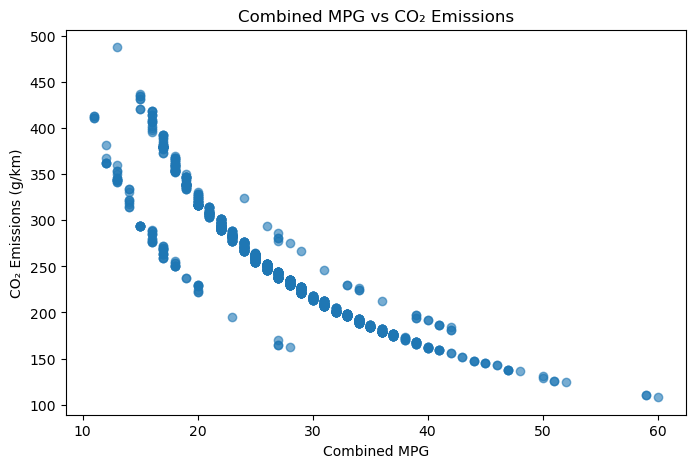

Correlation: -0.91


In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(df['FUELCONSUMPTION_COMB_MPG'], df['CO2EMISSIONS'], alpha=0.6)
plt.title('Combined MPG vs CO₂ Emissions')
plt.xlabel('Combined MPG')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show()

print("Correlation:", round(
    df['FUELCONSUMPTION_COMB_MPG'].corr(df['CO2EMISSIONS']), 2
))


### 🔎 Insight

- CO₂ emissions generally **decrease as combined MPG increases**.
- Vehicles with lower fuel economy tend to have higher CO₂ emissions.
- The relationship is strongly negative.

> ⭐ **Important Point:** Better fuel economy is generally associated with lower CO₂ emissions.


## 18. Engine Size vs CO₂ Emissions

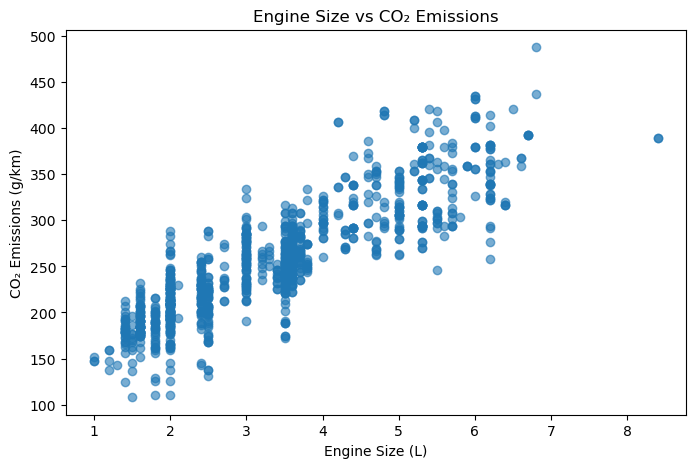

Correlation: 0.87


In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(df['ENGINESIZE'], df['CO2EMISSIONS'], alpha=0.6)
plt.title('Engine Size vs CO₂ Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show()

print("Correlation:", round(
    df['ENGINESIZE'].corr(df['CO2EMISSIONS']), 2
))


### 🔎 Insight

- CO₂ emissions generally increase as engine size increases.
- Smaller engines tend to have lower emission values.
- Larger engines generally show higher emission levels.

> ⭐ **Important Point:** Engine size has a strong positive association with CO₂ emissions.


## 19. Cylinders vs CO₂ Emissions

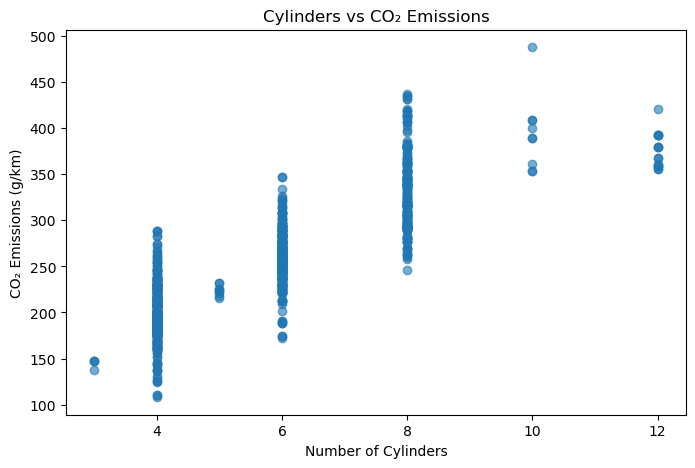

Correlation: 0.85


In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(df['CYLINDERS'], df['CO2EMISSIONS'], alpha=0.6)
plt.title('Cylinders vs CO₂ Emissions')
plt.xlabel('Number of Cylinders')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show()

print("Correlation:", round(
    df['CYLINDERS'].corr(df['CO2EMISSIONS']), 2
))


### 🔎 Insight

- CO₂ emissions generally increase with the number of cylinders.
- 4- and 6-cylinder vehicles are common and cover a wide emission range.
- Vehicles with 8 or more cylinders generally show higher emission levels.

> ⭐ **Important Point:** Cylinder count has a positive association with CO₂ emissions.


## 20. City vs Highway Fuel Consumption

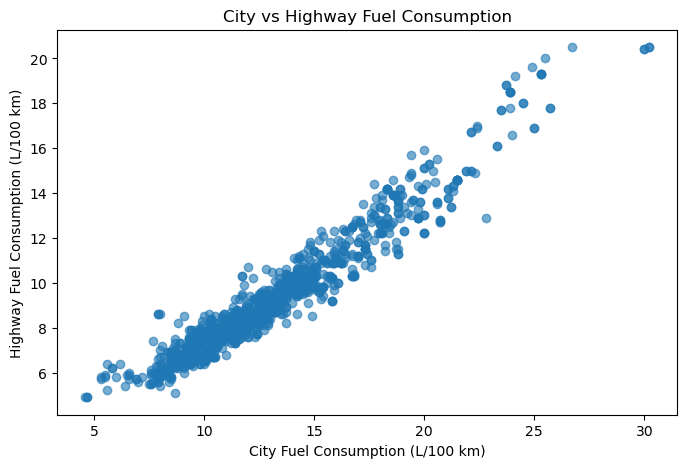

Correlation: 0.97


In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['FUELCONSUMPTION_CITY'],
    df['FUELCONSUMPTION_HWY'],
    alpha=0.6
)
plt.title('City vs Highway Fuel Consumption')
plt.xlabel('City Fuel Consumption (L/100 km)')
plt.ylabel('Highway Fuel Consumption (L/100 km)')
plt.show()

print("Correlation:", round(
    df['FUELCONSUMPTION_CITY'].corr(df['FUELCONSUMPTION_HWY']), 2
))


### 🔎 Insight

- Vehicles with high city fuel consumption generally also have high highway fuel consumption.
- The two fuel-consumption measures have a strong positive relationship.
- Highway consumption is generally lower than city consumption.

> ⭐ **Important Point:** City and highway fuel consumption are strongly related.


## 21. Fuel Type vs CO₂ Emissions

,count,mean,median
FUELTYPE,,,
E,92,291.09,285.00
Z,434,268.53,259.00
X,514,241.10,230.00
D,27,227.78,224.00


C:\Users\pradh\AppData\Local\Temp\ipykernel_19448\3658316802.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


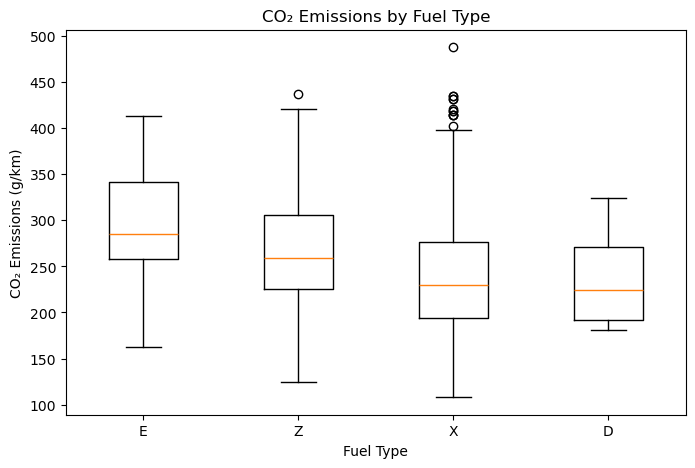

In [27]:
fuel_co2 = (
    df.groupby('FUELTYPE')['CO2EMISSIONS']
      .agg(['count', 'mean', 'median'])
      .sort_values('mean', ascending=False)
)

display(fuel_co2)

plt.figure(figsize=(8, 5))
plt.boxplot(
    [df.loc[df['FUELTYPE'] == fuel, 'CO2EMISSIONS'].dropna()
     for fuel in fuel_co2.index],
    labels=fuel_co2.index
)
plt.title('CO₂ Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show()


### 🔎 Insight

- Average CO₂ emissions differ across fuel types.
- The number of observations is unequal across fuel categories.
- The box plot shows variation within each fuel type.

> ⭐ **Important Point:** Fuel type is associated with different emission patterns, but sample size should be considered.


## 22. Vehicle Class vs CO₂ Emissions

,count,mean,median
VEHICLECLASS,,,
VAN - PASSENGER,25,401.00,411.00
VAN - CARGO,22,361.50,362.00
PICKUP TRUCK - STANDARD,62,309.10,303.50
SUV - STANDARD,110,307.67,298.00
PICKUP TRUCK - SMALL,12,284.25,287.50
FULL-SIZE,86,267.65,260.00
TWO-SEATER,71,265.68,244.00
MINIVAN,14,260.14,263.00
SUBCOMPACT,65,252.62,244.00


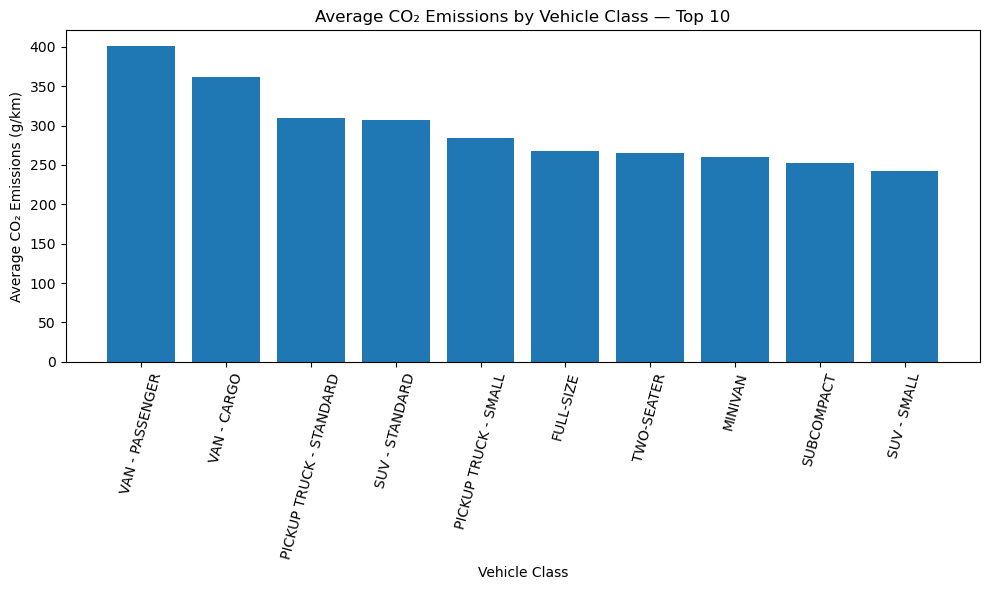

In [28]:
class_co2 = (
    df.groupby('VEHICLECLASS')['CO2EMISSIONS']
      .agg(['count', 'mean', 'median'])
      .sort_values('mean', ascending=False)
)

display(class_co2)

top_classes = class_co2.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_classes.index, top_classes['mean'])
plt.title('Average CO₂ Emissions by Vehicle Class — Top 10')
plt.xlabel('Vehicle Class')
plt.ylabel('Average CO₂ Emissions (g/km)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


### 🔎 Insight

- CO₂ emissions vary considerably between vehicle classes.
- Larger/heavier vehicle categories can show higher average emissions.
- Smaller passenger-oriented categories generally show lower average emissions.

> ⭐ **Important Point:** Vehicle class captures differences in vehicle size and use that can help explain emission differences.


## 23. Transmission vs CO₂ Emissions

,count,mean,median
TRANSMISSION,,,
A4,45,329.02,360.00
A7,12,314.00,307.00
A5,30,298.90,295.50
AS8,80,290.21,289.00
AS7,76,274.21,267.00
AM7,34,267.85,262.00
A8,87,265.64,253.00
A6,222,263.05,256.50
AS5,10,261.10,268.00


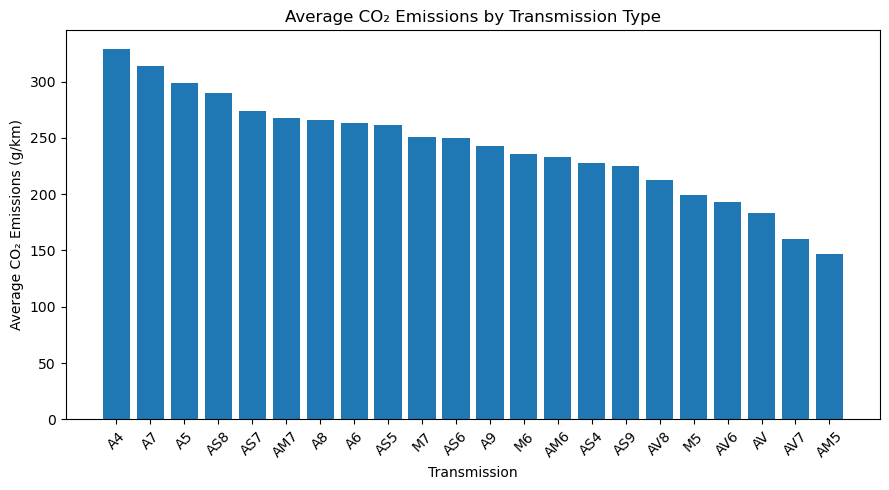

In [29]:
trans_co2 = (
    df.groupby('TRANSMISSION')['CO2EMISSIONS']
      .agg(['count', 'mean', 'median'])
      .sort_values('mean', ascending=False)
)

display(trans_co2)

plt.figure(figsize=(9, 5))
plt.bar(trans_co2.index, trans_co2['mean'])
plt.title('Average CO₂ Emissions by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Average CO₂ Emissions (g/km)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 🔎 Insight

- Average emissions differ across transmission categories.
- Transmission should be interpreted together with engine size, cylinders, vehicle class, and fuel type.
- Some transmission categories have fewer observations.

> ⭐ **Important Point:** Transmission may be associated with emissions, but it should not be interpreted in isolation.


## 24. Manufacturer vs Average CO₂ Emissions

,count,mean,median
MAKE,,,
LAMBORGHINI,3,394.00,400.00
SRT,2,389.00,389.00
ROLLS-ROYCE,7,381.00,393.00
BENTLEY,8,359.00,368.00
ASTON MARTIN,7,351.57,354.00
GMC,49,328.24,322.00
MASERATI,6,319.67,317.50
LAND ROVER,19,307.84,331.00
RAM,13,291.23,285.00


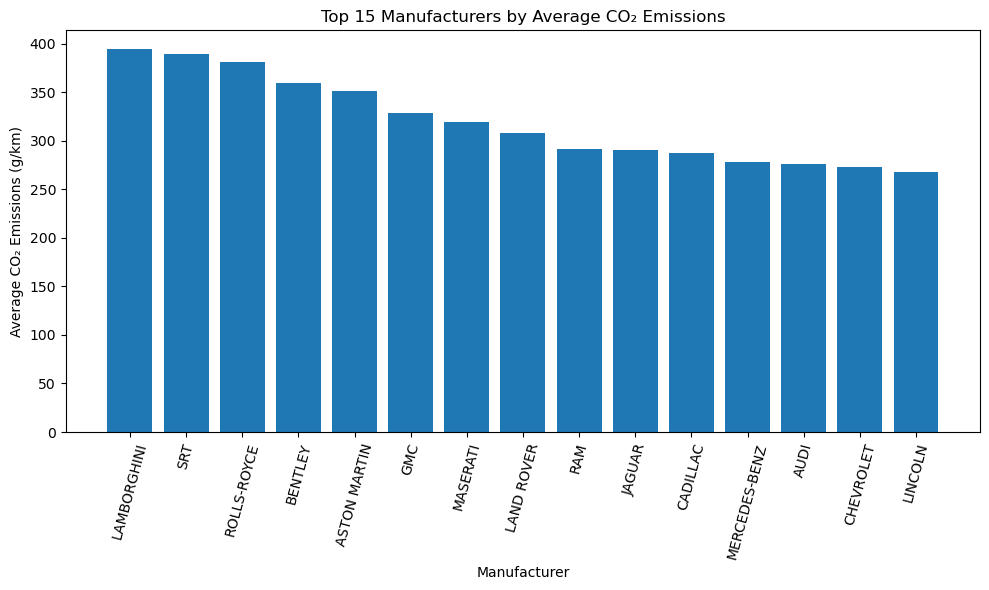

In [30]:
make_co2 = (
    df.groupby('MAKE')['CO2EMISSIONS']
      .agg(['count', 'mean', 'median'])
      .sort_values('mean', ascending=False)
)

display(make_co2.head(15))

top_makes = make_co2.head(15)

plt.figure(figsize=(10, 6))
plt.bar(top_makes.index, top_makes['mean'])
plt.title('Top 15 Manufacturers by Average CO₂ Emissions')
plt.xlabel('Manufacturer')
plt.ylabel('Average CO₂ Emissions (g/km)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


### 🔎 Insight

- Average CO₂ emissions vary across manufacturers.
- Manufacturer differences can reflect differences in vehicle classes, engine sizes, and powertrains.
- Manufacturers with very few observations should be interpreted cautiously.

> ⭐ **Important Point:** Manufacturer-level comparisons should be considered alongside vehicle characteristics.


## 25. Correlation Analysis

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
MODELYEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENGINESIZE,NaN,1.00,0.93,0.83,0.78,0.82,-0.81,0.87
CYLINDERS,NaN,0.93,1.00,0.80,0.72,0.78,-0.77,0.85
FUELCONSUMPTION_CITY,NaN,0.83,0.80,1.00,0.97,1.00,-0.94,0.90
FUELCONSUMPTION_HWY,NaN,0.78,0.72,0.97,1.00,0.99,-0.89,0.86
FUELCONSUMPTION_COMB,NaN,0.82,0.78,1.00,0.99,1.00,-0.93,0.89
FUELCONSUMPTION_COMB_MPG,NaN,-0.81,-0.77,-0.94,-0.89,-0.93,1.00,-0.91
CO2EMISSIONS,NaN,0.87,0.85,0.90,0.86,0.89,-0.91,1.00


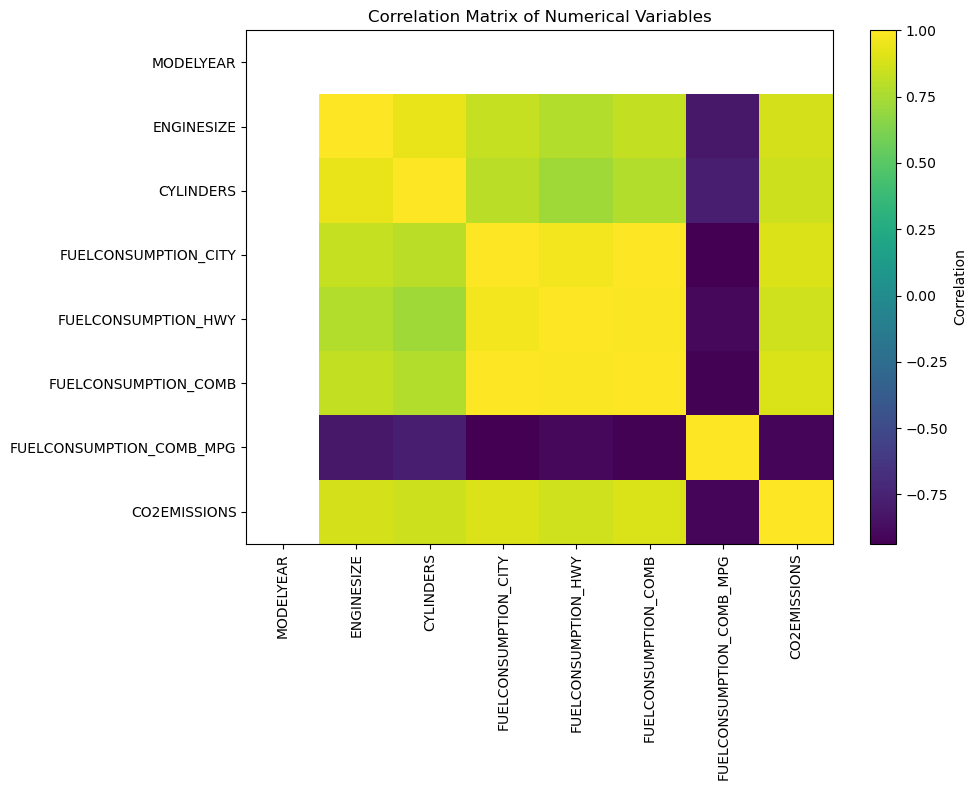

In [31]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

display(corr.round(2))

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()


### 🔎 Insight

- Engine size, cylinder count, and fuel-consumption measures show strong positive relationships with CO₂ emissions.
- Combined MPG has a strong negative relationship with CO₂ emissions.
- Fuel-consumption variables are strongly related to one another.

> ⭐ **Important Point:** Fuel consumption, engine size, cylinders, and MPG are key numerical variables for understanding CO₂ emissions.


## 26. IQR Outlier Analysis for Numerical Variables

In [32]:
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': count
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(
    'Outlier Count', ascending=False
)

display(outlier_df)


,Column,Lower Bound,Upper Bound,Outlier Count
4,FUELCONSUMPTION_HWY,2.47,15.88,35
5,FUELCONSUMPTION_COMB,2.47,19.88,32
3,FUELCONSUMPTION_CITY,2.30,23.50,26
6,FUELCONSUMPTION_COMB_MPG,6.00,46.00,13
7,CO2EMISSIONS,76.50,424.50,6
1,ENGINESIZE,-1.45,7.75,2
0,MODELYEAR,2014.00,2014.00,0
2,CYLINDERS,-2.00,14.00,0


### 🔎 Insight

- Outlier counts vary across numerical variables.
- Fuel-consumption and emissions variables can contain high-end observations.
- Outliers should be investigated before deciding whether they represent errors.

> ⭐ **Important Point:** Outlier detection is part of EDA; removal should always have a clear justification.


## 27. Highest and Lowest Emitting Vehicles

In [33]:
vehicle_cols = [
    'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE',
    'CYLINDERS', 'FUELTYPE', 'FUELCONSUMPTION_COMB',
    'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'
]

available_cols = [c for c in vehicle_cols if c in df.columns]

print("Highest CO₂ emissions:")
display(df.nlargest(10, 'CO2EMISSIONS')[available_cols])

print("\nLowest CO₂ emissions:")
display(df.nsmallest(10, 'CO2EMISSIONS')[available_cols])


Highest CO₂ emissions:


,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,FUELTYPE,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
349,FORD,E350 WAGON,VAN - PASSENGER,6.80,10,X,21.20,13,488
75,BENTLEY,MULSANNE,MID-SIZE,6.80,8,Z,19.00,15,437
227,CHEVROLET,EXPRESS 3500 PASSENGER,VAN - PASSENGER,6.00,8,X,18.90,15,435
451,GMC,SAVANA 3500 PASSENGER,VAN - PASSENGER,6.00,8,X,18.90,15,435
224,CHEVROLET,EXPRESS 2500 PASSENGER,VAN - PASSENGER,6.00,8,X,18.80,15,432
448,GMC,SAVANA 2500 PASSENGER,VAN - PASSENGER,6.00,8,X,18.80,15,432
350,FORD,E350 WAGON FFV,VAN - PASSENGER,5.40,8,X,18.30,15,421
633,LAMBORGHINI,AVENTADOR COUPE,TWO-SEATER,6.50,12,Z,18.30,15,421
226,CHEVROLET,EXPRESS 3500 PASSENGER,VAN - PASSENGER,4.80,8,X,18.20,16,419
450,GMC,SAVANA 3500 PASSENGER,VAN - PASSENGER,4.80,8,X,18.20,16,419



Lowest CO₂ emissions:


,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,FUELTYPE,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
988,TOYOTA,PRIUS c,COMPACT,1.50,4,X,4.70,60,108
487,HONDA,ACCORD HYBRID,MID-SIZE,2.00,4,X,4.80,59,110
987,TOYOTA,PRIUS,MID-SIZE,1.80,4,X,4.80,59,110
1042,VOLKSWAGEN,JETTA TURBO HYBRID,COMPACT,1.40,4,Z,5.40,52,124
415,FORD,FUSION HYBRID,MID-SIZE,2.00,4,X,5.50,51,126
989,TOYOTA,PRIUS v,STATION WAGON - MID-SIZE,1.80,4,X,5.50,51,126
655,LEXUS,CT 200h,COMPACT,1.80,4,X,5.60,50,129
970,TOYOTA,CAMRY HYBRID LE,MID-SIZE,2.50,4,X,5.70,50,131
2,ACURA,ILX HYBRID,COMPACT,1.50,4,Z,5.90,48,136
342,FORD,C-MAX HYBRID,FULL-SIZE,2.00,4,X,6.00,47,138


### 🔎 Insight

- The highest-emission vehicles can be examined for common characteristics such as larger engines, more cylinders, and higher fuel consumption.
- The lowest-emission vehicles can be examined for smaller engines and better fuel economy.

> ⭐ **Important Point:** Extreme individual records help explain the upper and lower ends of CO₂ emissions.


## 28. Model Year Analysis

,count,mean,median
MODELYEAR,,,
2014,1067,256.23,251.00


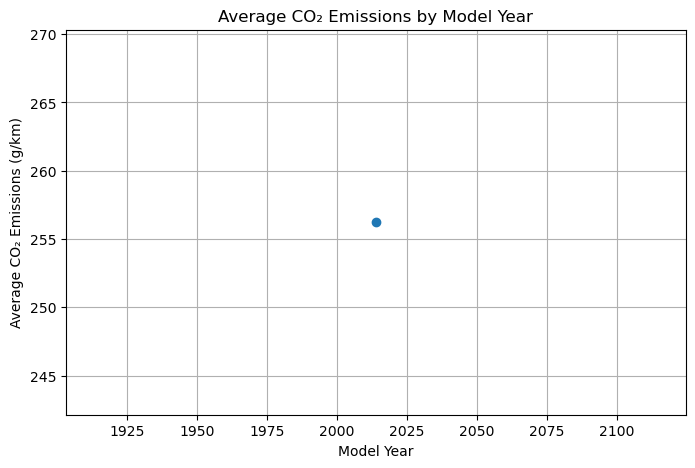

In [34]:
year_co2 = (
    df.groupby('MODELYEAR')['CO2EMISSIONS']
      .agg(['count', 'mean', 'median'])
      .sort_index()
)

display(year_co2)

plt.figure(figsize=(8, 5))
plt.plot(year_co2.index, year_co2['mean'], marker='o')
plt.title('Average CO₂ Emissions by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average CO₂ Emissions (g/km)')
plt.grid(True)
plt.show()


### 🔎 Insight

- Model year allows us to examine how average emissions vary across the years represented in the dataset.
- Year-to-year differences should be interpreted alongside changes in vehicle mix and technology.
- This is a descriptive trend, not proof that model year alone causes changes.

> ⭐ **Important Point:** Model year can reveal emission trends, but vehicle composition also matters.


## 29. Average Combined Fuel Consumption by Fuel Type

,count,mean,median
FUELTYPE,,,
E,92,18.19,17.80
Z,434,11.68,11.25
X,514,10.48,10.00
D,27,8.44,8.30


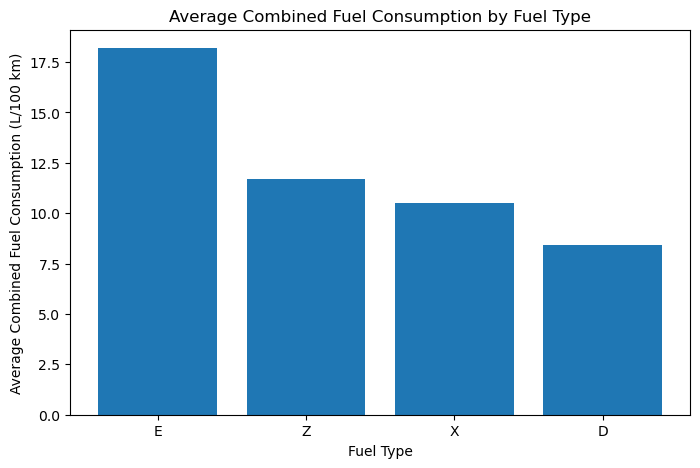

In [35]:
fuel_consumption = (
    df.groupby('FUELTYPE')['FUELCONSUMPTION_COMB']
      .agg(['count', 'mean', 'median'])
      .sort_values('mean', ascending=False)
)

display(fuel_consumption)

plt.figure(figsize=(8, 5))
plt.bar(fuel_consumption.index, fuel_consumption['mean'])
plt.title('Average Combined Fuel Consumption by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Combined Fuel Consumption (L/100 km)')
plt.show()


### 🔎 Insight

- Combined fuel consumption varies between fuel types.
- Mean and median help identify typical consumption and the influence of extreme values.
- Unequal sample sizes should be considered.

> ⭐ **Important Point:** Fuel type is useful for segmenting fuel-consumption behavior.


## 30. Engine Size Groups vs CO₂ Emissions

,count,mean,median
ENGINE_SIZE_GROUP,,,
<=2L,310,194.70,193.00
2-3L,205,232.86,230.00
3-4L,274,262.00,260.00
4-5L,112,318.71,315.00
>5L,166,348.32,354.00


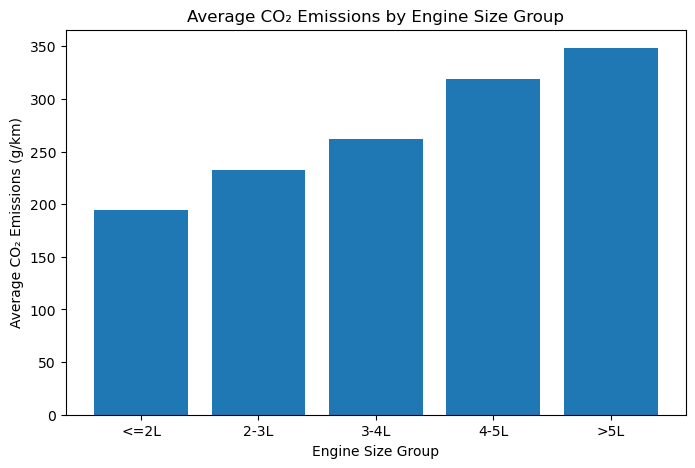

In [36]:
df['ENGINE_SIZE_GROUP'] = pd.cut(
    df['ENGINESIZE'],
    bins=[0, 2, 3, 4, 5, np.inf],
    labels=['<=2L', '2-3L', '3-4L', '4-5L', '>5L']
)

engine_group = (
    df.groupby('ENGINE_SIZE_GROUP', observed=False)['CO2EMISSIONS']
      .agg(['count', 'mean', 'median'])
)

display(engine_group)

plt.figure(figsize=(8, 5))
plt.bar(engine_group.index.astype(str), engine_group['mean'])
plt.title('Average CO₂ Emissions by Engine Size Group')
plt.xlabel('Engine Size Group')
plt.ylabel('Average CO₂ Emissions (g/km)')
plt.show()


### 🔎 Insight

- Average CO₂ emissions generally rise as engine-size groups increase.
- Grouping a continuous variable makes the pattern easier to communicate.

> ⭐ **Important Point:** Engine-size grouping provides a business-friendly view of the engine/emission relationship.


## 31. Final EDA Summary

### 🔎 Key Findings

1. The dataset contains many manufacturers and vehicle classes, with uneven representation.
2. Most vehicles have engine sizes around **2L–4L**.
3. **4- and 6-cylinder vehicles** are the most common groups.
4. City fuel consumption is generally higher than highway fuel consumption.
5. Most combined fuel consumption values fall around **7–13 L/100 km**.
6. Higher combined MPG is strongly associated with lower CO₂ emissions.
7. Larger engines generally correspond to higher CO₂ emissions.
8. Vehicles with more cylinders generally show higher CO₂ emissions.
9. CO₂ emissions differ across vehicle classes and fuel types.
10. Several high-consumption and high-emission observations can be identified as outliers.
11. Fuel consumption, engine size, cylinders, and MPG show strong relationships with CO₂ emissions.

> ⭐ **Important Point:** The main descriptive pattern is that **higher fuel consumption and larger engine-related specifications are associated with higher CO₂ emissions**, while **higher MPG is associated with lower emissions**.
